# Coin Detection

**Name :** JOHN PALL .M **Reg. No :** 212224040140

# Coin Detection using Morphological Operations and Thresholding

## Aim

In this project, you will work with an image and apply morphological operations and thresholding techniques to detect and count the total number of coins present in the image.



### Note:

- **Do not remove intermediate images.**
- Display all key intermediate images (grayscale, thresholded, binary, morphological result, final detections).
- Document your findings and observations for each step.
- Print the total number of coins detected using both **blob detection** and **contour detection** methods.

## Expected Output

All expected output images and results are already displayed.
Enter your code only inside the blocks marked as:

In [30]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Read Image

In [46]:
image = cv2.imread("C:\\Users\\HAI\\Desktop\\sathish\\dipt\\Coin-Detection-using-OpenCV-in-Python\\Coin.png")

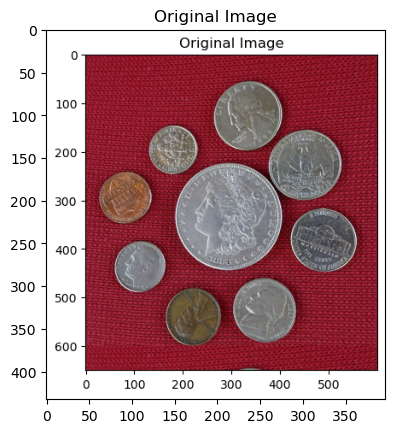

In [47]:
plt.imshow(image[:,:,::-1]);
plt.title("Original Image")
plt.show()

# Step 2: Convert Image to Grayscale

In [48]:
imageGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

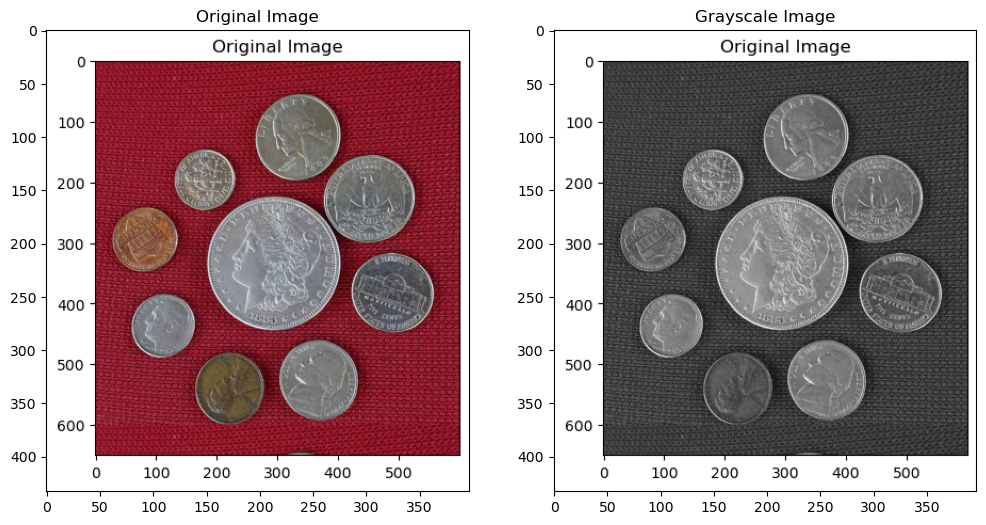

In [49]:
plt.figure(figsize=(12,12))
plt.subplot(121);
plt.imshow(image[:,:,::-1]);
plt.title("Original Image")
plt.subplot(122); 
plt.imshow(imageGray,cmap='gray');
plt.title("Grayscale Image"); 
plt.show()

# Step 3: Split Image into R,G,B Channels

In [50]:
imageB, imageG, imageR = cv2.split(image)

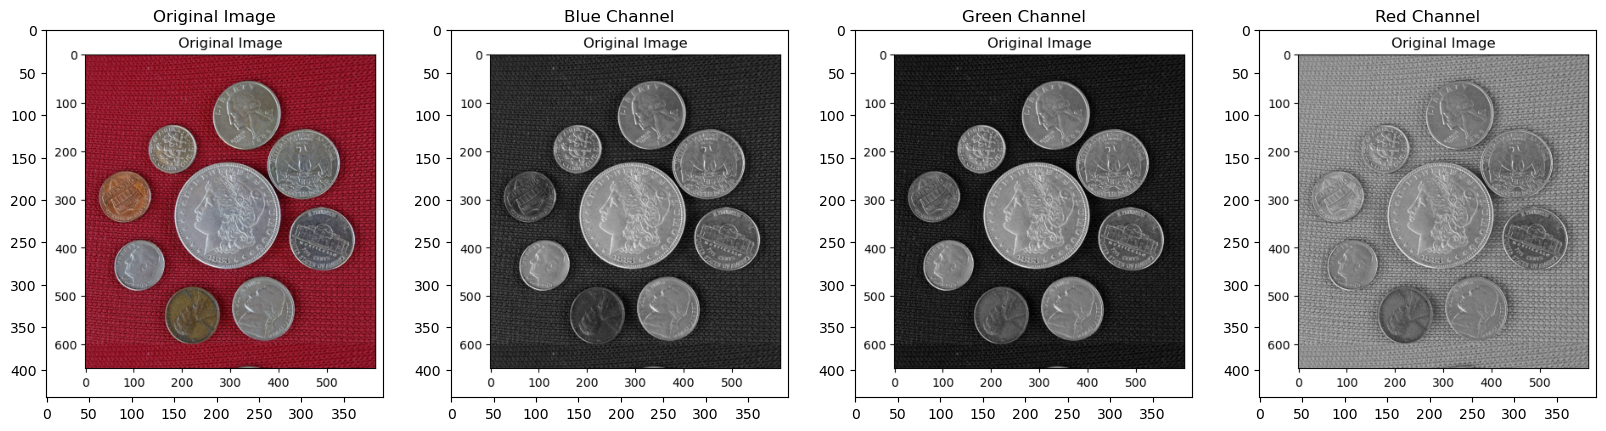

In [51]:
plt.figure(figsize=(20,12))
plt.subplot(141);
plt.imshow(image[:,:,::-1]);
plt.title("Original Image")
plt.subplot(142);
plt.imshow(imageB,cmap='gray');
plt.title("Blue Channel")
plt.subplot(143);
plt.imshow(imageG,cmap='gray');
plt.title("Green Channel")
plt.subplot(144);
plt.imshow(imageR,cmap='gray');
plt.title("Red Channel");
plt.show()

# Step 4: Perform Thresholding

You will have to carry out this step with different threshold values to see which one suits you the most. Do not remove those intermediate images and make sure to document your findings.

In [52]:
thresh=20
maxValue=255
th,dst_bin_inv=cv2.threshold(imageG,thresh,maxValue,cv2.THRESH_BINARY_INV)

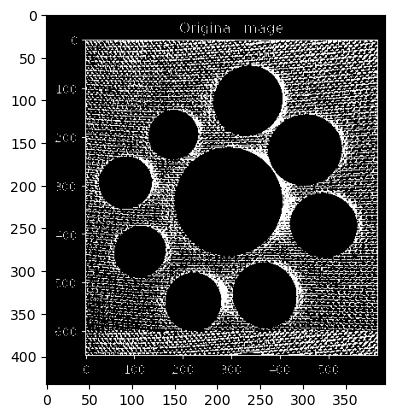

In [53]:
plt.imshow(dst_bin_inv, cmap='gray')
plt.show()

# Step 5: Perform morphological operations

You will have to carry out this step with different kernel size, kernel shape and morphological operations to see which one (or more) suits you the most. Do not remove those intermediate images and make sure to document your findings.

In [54]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
imageDilated2 = cv2.dilate(dst_bin_inv, kernel, iterations=2)

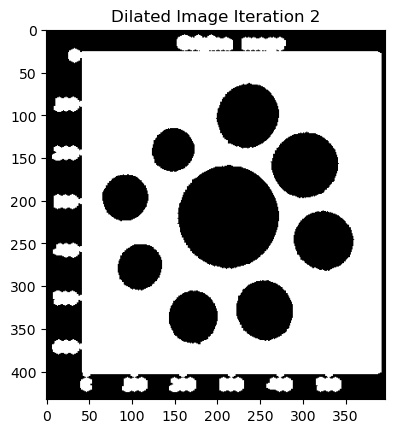

In [55]:
plt.imshow(imageDilated2,cmap='gray');
plt.title('Dilated Image Iteration 2');
plt.show()

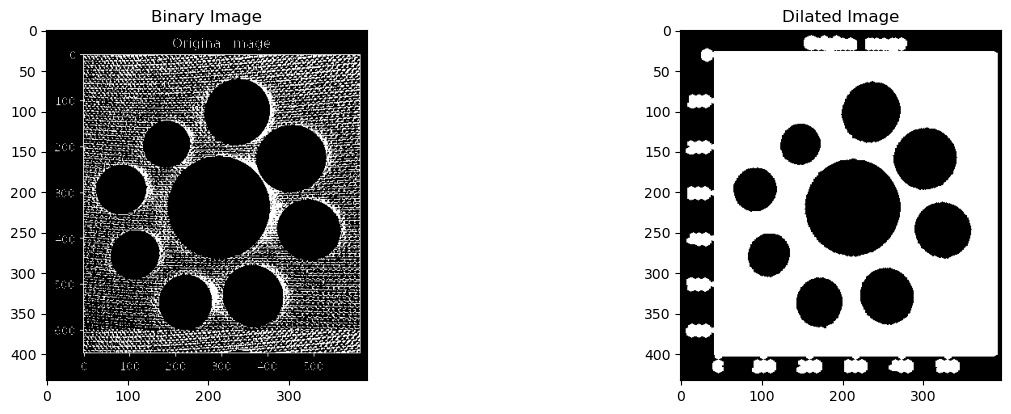

In [56]:
plt.figure(figsize=(15,10))

plt.subplot(221)
plt.imshow(dst_bin_inv, cmap='gray')
plt.title("Binary Image")

plt.subplot(222)
plt.imshow(imageDilated2, cmap='gray')
plt.title("Dilated Image")

plt.show()

In [57]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11,11))
imageEroded = cv2.erode(imageDilated2,kernel)

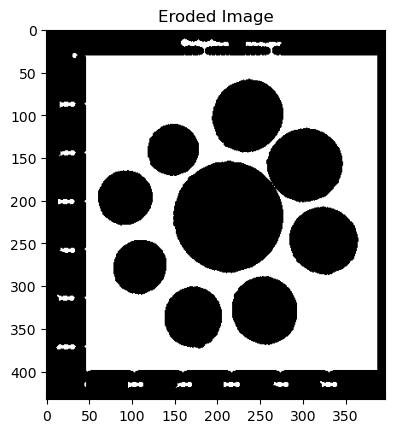

In [58]:
plt.imshow(imageEroded,cmap='gray');
plt.title("Eroded Image");
plt.show()

# Step 5: Create SimpleBlobDetector

In [59]:
# Set up the SimpleBlobdetector with default parameters.
params = cv2.SimpleBlobDetector_Params()

params.blobColor = 0

params.minDistBetweenBlobs = 2

# Filter by Area.
params.filterByArea = False

# Filter by Circularity
params.filterByCircularity = True
params.minCircularity = 0.8

# Filter by Convexity
params.filterByConvexity = True
params.minConvexity = 0.8

# Filter by Inertia
params.filterByInertia =True
params.minInertiaRatio = 0.8

In [60]:
# Create SimpleBlobDetector
detector = cv2.SimpleBlobDetector_create(params)

# Step 6: Detect Coins

## Hints
Use detector.detect(image) to detect the blobs (coins). The output of the function is a list of keypoints where each keypoint is unique for each blob.

Print the number of coins detected as well.

In [61]:
keypoints = detector.detect(imageEroded)

In [62]:
print(f"Number of coins detected: {len(keypoints)}")

Number of coins detected: 7
